# Vesuvius Surface Detection — SuPreM SegResNet (Run 6)

3D segmentation of papyrus surfaces in CT scans of Herculaneum scrolls.

**Metric:** `0.30 * TopoScore + 0.35 * SurfaceDice@tau=2 + 0.35 * VOI_score`

**Changes from Run 5:**
- **Discriminative LR** — 3 param groups (encoder/decoder/head) with geometrically spaced LRs via `slice(LR/100, LR)`. Encoder (SuPreM pre-trained) gets gentle fine-tuning, head (random init) gets aggressive learning.
- **Downsampled competition metric** — 4x downsample (80^3) before Betti matching, ~1s per volume instead of 20+ minutes. Topology is a coarse property, so downsampling preserves the signal.

**Carried from Run 5:**
- Competition metric monitoring (TopoScore + SurfaceDice + VOI) on val volumes each epoch
- Loss: 0.2*BCE + 0.2*Dice + 0.3*clDice + 0.3*Boundary (all masked for label=2)
- MONAI SegResNet (4.7M params) with SuPreM pre-trained weights
- Threshold tuning + post-processing at inference time

## 1. Imports & Config

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import numpy as np
import pandas as pd
import tifffile
from pathlib import Path
import matplotlib.pyplot as plt
from fastai.learner import Learner
from fastai.callback.schedule import lr_find, fit_one_cycle
from fastai.callback.tracker import SaveModelCallback
from fastai.callback.fp16 import MixedPrecision
from fastai.data.core import DataLoaders
from fastai.metrics import Metric
from monai.networks.nets import SegResNet
from scipy.ndimage import distance_transform_edt, label as scipy_label
from scipy.ndimage import binary_closing
from scipy.ndimage import zoom as scipy_zoom
from topometrics.leaderboard import compute_leaderboard_score
import random
import zipfile

# Config
ROOT = Path("/home/mongomatt/Projects/vesuvius")
TRAIN_IMG = ROOT / "train_images"
TRAIN_LBL = ROOT / "train_labels"
TEST_IMG = ROOT / "test_images"
CKPT_DIR = ROOT / "checkpoints"
CKPT_DIR.mkdir(exist_ok=True)
PRETRAINED_WEIGHTS = ROOT / "pretrained_weights" / "supervised_suprem_segresnet_2100.pth"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
PATCH_SIZE = 128       # Train on 128^3 random crops
BATCH_SIZE = 2
NUM_WORKERS = 8
EPOCHS = 30
SEED = 42
N_VAL_VOLUMES = 5      # Number of val volumes for competition metric eval
COMP_THRESHOLD = 0.5   # Binarization threshold for competition metric
METRIC_DOWNSAMPLE = 4  # Downsample factor for competition metric (320 -> 80)
LR = 1e-3              # Will be overwritten by lr_find

torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

print(f"Device: {DEVICE}")
print(f"CUDA: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'N/A'}")
print(f"Patch size: {PATCH_SIZE}^3, Batch size: {BATCH_SIZE}")
print(f"Pretrained weights: {PRETRAINED_WEIGHTS.name}")
print(f"Competition metric: {N_VAL_VOLUMES} val volumes, threshold={COMP_THRESHOLD}, downsample={METRIC_DOWNSAMPLE}x")

Device: cuda
CUDA: NVIDIA GeForce RTX 5090
Patch size: 128^3, Batch size: 2
Pretrained weights: supervised_suprem_segresnet_2100.pth
Competition metric: 5 val volumes, threshold=0.5, downsample=4x


## 2. Data Exploration

In [2]:
train_df = pd.read_csv(ROOT / "train.csv")
print(f"Training samples: {len(train_df)}")
print(f"Unique scroll_ids: {train_df.scroll_id.nunique()}")
print()
print(train_df.scroll_id.value_counts())

Training samples: 806
Unique scroll_ids: 6

scroll_id
34117    382
35360    176
26010    130
26002     88
44430     17
53997     13
Name: count, dtype: int64


In [3]:
# Load a sample volume and label — pick one that exists on disk
sample_id = None
for sid in train_df.id:
    if (TRAIN_IMG / f"{sid}.tif").exists():
        sample_id = sid
        break

sample_img = tifffile.imread(TRAIN_IMG / f"{sample_id}.tif")
sample_lbl = tifffile.imread(TRAIN_LBL / f"{sample_id}.tif")

print(f"Sample ID: {sample_id}")
print(f"Image shape: {sample_img.shape}, dtype: {sample_img.dtype}")
print(f"Label shape: {sample_lbl.shape}, dtype: {sample_lbl.dtype}")
print(f"Label unique values: {np.unique(sample_lbl)}")

fg_pct = (sample_lbl == 1).sum() / sample_lbl.size * 100
bg_pct = (sample_lbl == 0).sum() / sample_lbl.size * 100
ign_pct = (sample_lbl == 2).sum() / sample_lbl.size * 100
print(f"\nLabel distribution: bg={bg_pct:.1f}%, fg={fg_pct:.1f}%, unlabeled={ign_pct:.1f}%")

Sample ID: 2290837
Image shape: (320, 320, 320), dtype: uint8
Label shape: (320, 320, 320), dtype: uint8
Label unique values: [0 1 2]

Label distribution: bg=37.3%, fg=4.9%, unlabeled=57.8%


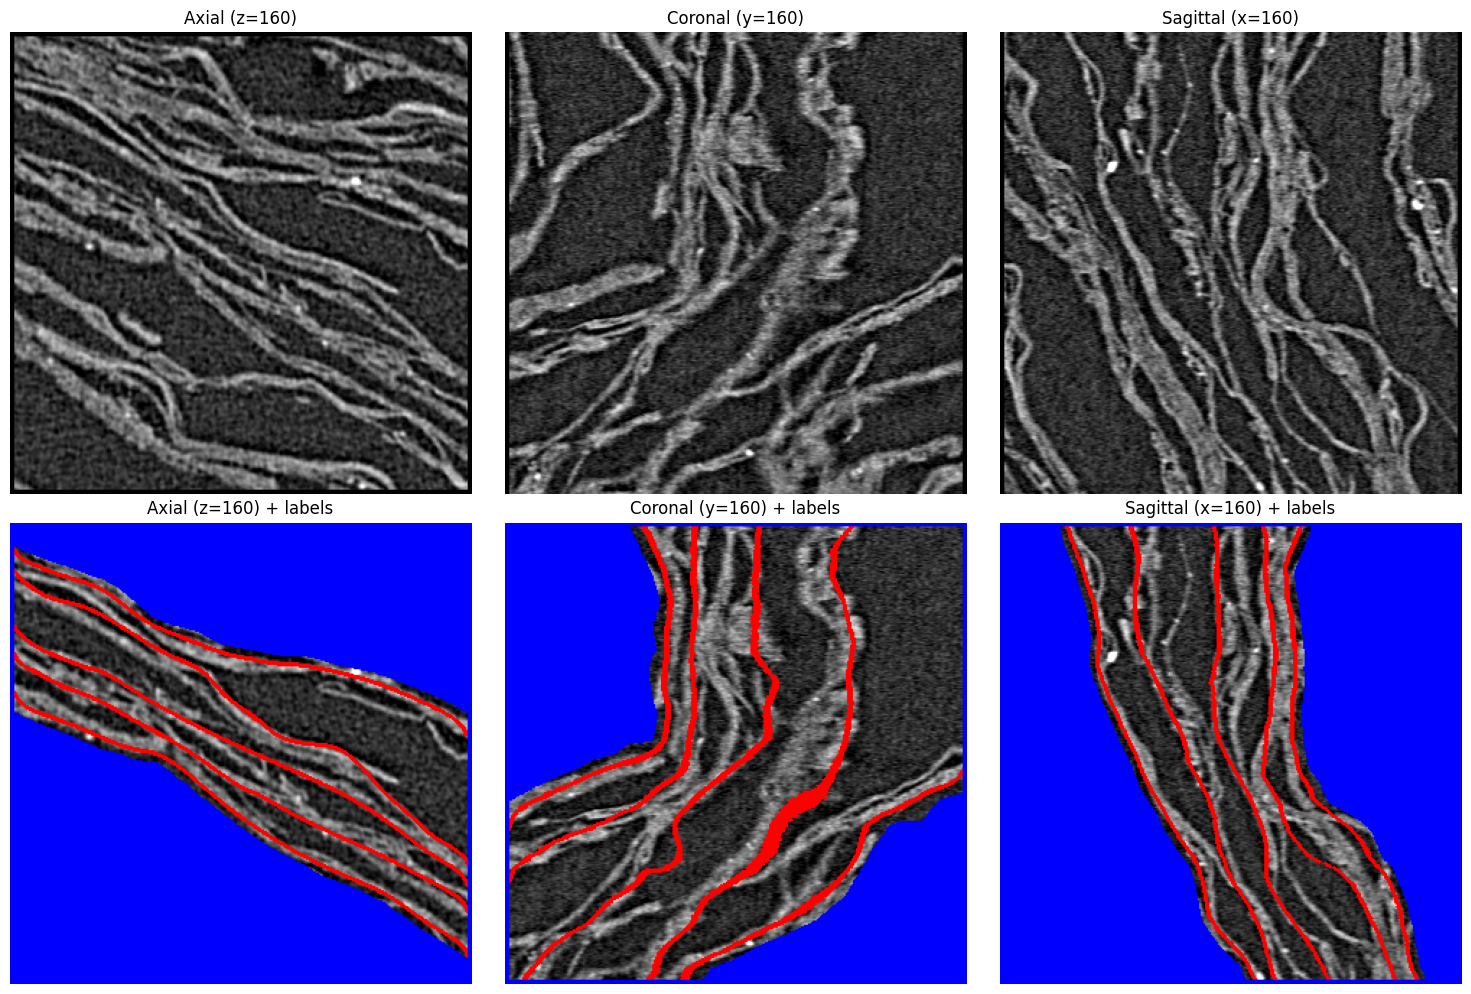

In [4]:
# Visualize 3 orthogonal slices through the volume
mid = sample_img.shape[0] // 2

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Row 1: raw CT slices
axes[0, 0].imshow(sample_img[mid, :, :], cmap="gray")
axes[0, 0].set_title(f"Axial (z={mid})")
axes[0, 1].imshow(sample_img[:, mid, :], cmap="gray")
axes[0, 1].set_title(f"Coronal (y={mid})")
axes[0, 2].imshow(sample_img[:, :, mid], cmap="gray")
axes[0, 2].set_title(f"Sagittal (x={mid})")

# Row 2: label overlay (red = foreground, blue = unlabeled)
for i, (slc_img, slc_lbl, title) in enumerate([
    (sample_img[mid], sample_lbl[mid], f"Axial (z={mid})"),
    (sample_img[:, mid], sample_lbl[:, mid], f"Coronal (y={mid})"),
    (sample_img[:, :, mid], sample_lbl[:, :, mid], f"Sagittal (x={mid})"),
]):
    rgb = np.stack([slc_img]*3, axis=-1).astype(float) / 255.0
    rgb[slc_lbl == 1] = [1, 0, 0]  # foreground = red
    rgb[slc_lbl == 2] = [0, 0, 1]  # unlabeled = blue
    axes[1, i].imshow(rgb)
    axes[1, i].set_title(f"{title} + labels")

for ax in axes.flat:
    ax.axis("off")
plt.tight_layout()
plt.show()

## 3. Dataset

In [5]:
def compute_signed_distance_map(label, mask):
    """
    Compute signed distance transform from ground truth boundary.
    Negative inside foreground, positive outside, zero at boundary.
    Normalized by max distance so values are roughly in [-1, 1].
    Only computed within the valid mask (label != 2).
    """
    fg = label.astype(bool)
    bg = ~fg

    # Distance from foreground boundary (inside → negative, outside → positive)
    dist_inside = distance_transform_edt(fg)
    dist_outside = distance_transform_edt(bg)

    signed_dist = dist_outside - dist_inside

    # Normalize by max absolute distance for stable loss scaling
    max_dist = max(np.abs(signed_dist).max(), 1.0)
    signed_dist = signed_dist / max_dist

    # Zero out unlabeled regions
    signed_dist = signed_dist * mask

    return signed_dist.astype(np.float32)


class VesuviusDataset(Dataset):
    """3D volume dataset with random patch cropping for training."""

    def __init__(self, ids, img_dir, lbl_dir, patch_size=128, augment=False):
        self.ids = ids
        self.img_dir = Path(img_dir)
        self.lbl_dir = Path(lbl_dir)
        self.patch_size = patch_size
        self.augment = augment

    def __len__(self):
        return len(self.ids)

    def _random_crop(self, img, lbl, ps):
        """Extract a random ps^3 patch from the volume."""
        d, h, w = img.shape
        z = random.randint(0, d - ps)
        y = random.randint(0, h - ps)
        x = random.randint(0, w - ps)
        return img[z:z+ps, y:y+ps, x:x+ps], lbl[z:z+ps, y:y+ps, x:x+ps]

    def __getitem__(self, idx):
        vol_id = self.ids[idx]

        # Load volume and label
        img = tifffile.imread(self.img_dir / f"{vol_id}.tif")
        lbl = tifffile.imread(self.lbl_dir / f"{vol_id}.tif")

        # Random patch crop
        img, lbl = self._random_crop(img, lbl, self.patch_size)

        # Normalize to [0, 1]
        img = img.astype(np.float32) / 255.0

        # Mask: True where label is 0 or 1 (valid), False where label is 2 (ignore)
        mask = (lbl != 2).astype(np.float32)

        # Binary label: foreground=1, everything else=0
        label = (lbl == 1).astype(np.float32)

        # Signed distance transform for boundary loss
        dist_map = compute_signed_distance_map(label, mask)

        # Augmentations: random flips and 90-degree rotations
        if self.augment:
            for axis in range(3):
                if random.random() > 0.5:
                    img = np.flip(img, axis=axis).copy()
                    label = np.flip(label, axis=axis).copy()
                    mask = np.flip(mask, axis=axis).copy()
                    dist_map = np.flip(dist_map, axis=axis).copy()

            k = random.randint(0, 3)
            plane_axes = random.choice([(0, 1), (0, 2), (1, 2)])
            if k > 0:
                img = np.rot90(img, k=k, axes=plane_axes).copy()
                label = np.rot90(label, k=k, axes=plane_axes).copy()
                mask = np.rot90(mask, k=k, axes=plane_axes).copy()
                dist_map = np.rot90(dist_map, k=k, axes=plane_axes).copy()

        # Add channel dimension: (1, D, H, W)
        img = torch.from_numpy(img).unsqueeze(0)
        label = torch.from_numpy(label).unsqueeze(0)
        mask = torch.from_numpy(mask).unsqueeze(0)
        dist_map = torch.from_numpy(dist_map).unsqueeze(0)

        return img, (label, mask, dist_map)


# Quick test
test_ds = VesuviusDataset([sample_id], TRAIN_IMG, TRAIN_LBL,
                          patch_size=PATCH_SIZE, augment=False)
x, (y, m, d) = test_ds[0]
print(f"Image: {x.shape}, Label: {y.shape}, Mask: {m.shape}, DistMap: {d.shape}")
print(f"Image range: [{x.min():.2f}, {x.max():.2f}]")
print(f"DistMap range: [{d.min():.3f}, {d.max():.3f}]")
print(f"Label unique: {y.unique().tolist()}, Mask unique: {m.unique().tolist()}")

Image: torch.Size([1, 128, 128, 128]), Label: torch.Size([1, 128, 128, 128]), Mask: torch.Size([1, 128, 128, 128]), DistMap: torch.Size([1, 128, 128, 128])
Image range: [0.00, 1.00]
DistMap range: [-0.028, 0.240]
Label unique: [0.0, 1.0], Mask unique: [0.0, 1.0]


## 4. DataLoaders

In [6]:
# Split by scroll_id: hold out scroll 26002 for validation (88 volumes)
train_df = pd.read_csv(ROOT / "train.csv")

# Only keep IDs that have both image and label files on disk
available_ids = set(
    int(p.stem) for p in TRAIN_IMG.glob("*.tif")
) & set(
    int(p.stem) for p in TRAIN_LBL.glob("*.tif")
)
train_df = train_df[train_df.id.isin(available_ids)].reset_index(drop=True)

VAL_SCROLL = 26002
val_ids = train_df[train_df.scroll_id == VAL_SCROLL].id.tolist()
trn_ids = train_df[train_df.scroll_id != VAL_SCROLL].id.tolist()

print(f"Train: {len(trn_ids)} volumes, Val: {len(val_ids)} volumes")

trn_ds = VesuviusDataset(trn_ids, TRAIN_IMG, TRAIN_LBL,
                          patch_size=PATCH_SIZE, augment=True)
val_ds = VesuviusDataset(val_ids, TRAIN_IMG, TRAIN_LBL,
                          patch_size=PATCH_SIZE, augment=False)

trn_dl = DataLoader(trn_ds, batch_size=BATCH_SIZE, shuffle=True,
                    num_workers=NUM_WORKERS, pin_memory=True)
val_dl = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                    num_workers=NUM_WORKERS, pin_memory=True)

dls = DataLoaders(trn_dl, val_dl, device=DEVICE)
print("DataLoaders ready.")

Train: 704 volumes, Val: 82 volumes
DataLoaders ready.


## 5. SuPreM SegResNet Model

In [7]:
def create_segresnet_with_suprem_weights(weights_path, device="cpu"):
    """
    Create a MONAI SegResNet and load SuPreM supervised pre-trained weights.
    
    SuPreM was trained on 2,100 CT volumes with 25 organ classes.
    We load all layers except the final conv (which has out_channels=25
    in the checkpoint vs our out_channels=1).
    """
    # Match SuPreM's exact architecture config
    model = SegResNet(
        spatial_dims=3,
        in_channels=1,
        out_channels=1,        # binary segmentation (raw logits, no sigmoid)
        init_filters=16,       # channels: 16 -> 32 -> 64 -> 128
        blocks_down=[1, 2, 2, 4],
        blocks_up=[1, 1, 1],
        dropout_prob=0.2,      # add dropout for regularization
    )

    # Load SuPreM checkpoint
    ckpt = torch.load(weights_path, map_location=device, weights_only=False)
    pretrained = ckpt["net"]
    store_dict = model.state_dict()

    loaded, skipped = 0, 0
    for key in pretrained.keys():
        # Strip 'module.' prefix (SuPreM was trained with DataParallel)
        new_key = key.replace("module.", "")
        if new_key in store_dict:
            if "conv_final" in new_key:
                skipped += 1  # skip final conv (different out_channels)
                continue
            if store_dict[new_key].shape == pretrained[key].shape:
                store_dict[new_key] = pretrained[key]
                loaded += 1
            else:
                print(f"  Shape mismatch: {new_key}")
                skipped += 1
        else:
            skipped += 1

    model.load_state_dict(store_dict)
    print(f"SuPreM weights: loaded {loaded}/{loaded+skipped} params, skipped {skipped} (final conv)")
    return model


# Create model with pre-trained weights
model = create_segresnet_with_suprem_weights(PRETRAINED_WEIGHTS)

n_params = sum(p.numel() for p in model.parameters()) / 1e6
print(f"Model parameters: {n_params:.1f}M")

# Test forward pass
with torch.no_grad():
    dummy = torch.randn(1, 1, PATCH_SIZE, PATCH_SIZE, PATCH_SIZE)
    out = model(dummy)
    print(f"Input: {dummy.shape} -> Output: {out.shape}")

SuPreM weights: loaded 79/83 params, skipped 4 (final conv)
Model parameters: 4.7M
Input: torch.Size([1, 1, 128, 128, 128]) -> Output: torch.Size([1, 1, 128, 128, 128])


## 6. Loss Function

In [8]:
# --- clDice: topology-preserving loss via soft skeletons ---

def soft_erode_3d(img):
    """Soft erosion using min-pooling (negate, max-pool, negate)."""
    return -F.max_pool3d(-img, kernel_size=3, stride=1, padding=1)

def soft_dilate_3d(img):
    """Soft dilation using max-pooling."""
    return F.max_pool3d(img, kernel_size=3, stride=1, padding=1)

def soft_open_3d(img):
    """Soft morphological opening = erode then dilate."""
    return soft_dilate_3d(soft_erode_3d(img))

def soft_skeleton_3d(img, iters=5):
    """
    Compute soft skeleton via iterative erosion.
    skel = sum_i [ ReLU(erode^i(img) - open(erode^i(img))) ]
    """
    skel = F.relu(img - soft_open_3d(img))
    for _ in range(iters):
        img = soft_erode_3d(img)
        delta = F.relu(img - soft_open_3d(img))
        skel = skel + delta
    return skel

def soft_cldice(pred_sig, target, iters=5, smooth=1.0):
    """
    Compute clDice on 2x-downsampled volumes for memory efficiency.
    Topology is a coarse structural property, so 64^3 captures it well.
    """
    # Downsample 2x to reduce memory (128^3 -> 64^3)
    pred_ds = F.avg_pool3d(pred_sig, kernel_size=2)
    with torch.no_grad():
        target_ds = F.avg_pool3d(target, kernel_size=2)

    # Pred skeleton needs gradients for backprop
    skel_pred = soft_skeleton_3d(pred_ds, iters=iters)

    # Target skeleton does NOT need gradients
    with torch.no_grad():
        skel_target = soft_skeleton_3d(target_ds, iters=iters)

    # Topology precision: pred skeleton covered by target
    tprec = ((skel_pred * target_ds).sum() + smooth) / (skel_pred.sum() + smooth)
    # Topology sensitivity: target skeleton covered by pred
    tsens = ((skel_target * pred_ds).sum() + smooth) / (skel_target.sum() + smooth)

    cldice = 2.0 * tprec * tsens / (tprec + tsens + 1e-8)
    return cldice


# --- Boundary loss via signed distance transform ---

def boundary_loss(pred_sig, dist_map, mask):
    """
    Boundary loss: penalizes predictions far from the ground truth boundary.
    Uses signed distance transform (negative inside GT, positive outside).
    Minimizing mean(pred * dist_map) pushes predicted surface toward GT surface.

    Targets SurfaceDice@τ=2 component of competition metric.
    """
    # Multiply prediction probabilities by signed distance
    # - Predicting 1.0 where dist is positive (outside GT) → high penalty
    # - Predicting 1.0 where dist is negative (inside GT) → reward (negative loss)
    # - Predicting 0.0 anywhere → no contribution
    loss = (pred_sig * dist_map * mask).sum() / (mask.sum() + 1e-8)
    return loss


class MaskedCombinedLoss(nn.Module):
    """
    Combined loss: 0.2*BCE + 0.2*Dice + 0.3*clDice + 0.3*Boundary
    All masked to ignore unlabeled voxels (label=2).

    Each term targets a different aspect of the competition metric:
    - BCE: baseline voxel classification
    - Dice: volume overlap (class imbalance)
    - clDice: topology preservation → TopoScore (30%)
    - Boundary: surface accuracy → SurfaceDice@τ=2 (35%)
    """

    def __init__(self, bce_weight=0.2, dice_weight=0.2, cldice_weight=0.3,
                 boundary_weight=0.3, smooth=1.0, skel_iters=5):
        super().__init__()
        self.bce_weight = bce_weight
        self.dice_weight = dice_weight
        self.cldice_weight = cldice_weight
        self.boundary_weight = boundary_weight
        self.smooth = smooth
        self.skel_iters = skel_iters

    def forward(self, pred, target_tuple):
        target, mask, dist_map = target_tuple

        pred_sig = torch.sigmoid(pred)

        # Apply mask
        pred_masked = pred_sig * mask
        target_masked = target * mask

        # --- Masked BCE (on logits for numerical stability) ---
        bce = F.binary_cross_entropy_with_logits(pred, target, reduction='none')
        bce = (bce * mask).sum() / (mask.sum() + 1e-8)

        # --- Masked Dice ---
        intersection = (pred_masked * target_masked).sum()
        dice = (2.0 * intersection + self.smooth) / (
            pred_masked.sum() + target_masked.sum() + self.smooth
        )
        dice_loss = 1.0 - dice

        # --- Masked clDice (on downsampled patches) ---
        cldice = soft_cldice(pred_masked, target_masked,
                             iters=self.skel_iters, smooth=self.smooth)
        cldice_loss = 1.0 - cldice

        # --- Boundary loss ---
        bd_loss = boundary_loss(pred_sig, dist_map, mask)

        return (self.bce_weight * bce +
                self.dice_weight * dice_loss +
                self.cldice_weight * cldice_loss +
                self.boundary_weight * bd_loss)


class MaskedDiceMetric(Metric):
    """Dice coefficient metric (masked) for fastai Learner."""
    def __init__(self):
        self.reset()

    def reset(self):
        self.intersection = 0.0
        self.union = 0.0

    def accumulate(self, learn):
        pred = torch.sigmoid(learn.pred) > 0.5
        target, mask, _dist = learn.y
        pred_m = pred * mask
        tgt_m = target * mask
        self.intersection += (pred_m * tgt_m).sum().item()
        self.union += pred_m.sum().item() + tgt_m.sum().item()

    @property
    def value(self):
        return (2.0 * self.intersection + 1.0) / (self.union + 1.0)

    @property
    def name(self):
        return "dice"


# --- Sliding window inference (needed by CompetitionMetric during training) ---

def sliding_window_inference(model, volume, patch_size=128, stride=96, device="cuda"):
    """
    Run inference on a full 320^3 volume using overlapping patches.
    Overlapping regions are averaged for smoother predictions.
    """
    D, H, W = volume.shape
    ps = patch_size

    # Output accumulator and count (for averaging overlaps)
    output = np.zeros((D, H, W), dtype=np.float32)
    counts = np.zeros((D, H, W), dtype=np.float32)

    # Generate patch start positions
    def _positions(length, ps, stride):
        pos = list(range(0, length - ps, stride))
        if not pos or pos[-1] + ps < length:
            pos.append(length - ps)
        return pos

    z_pos = _positions(D, ps, stride)
    y_pos = _positions(H, ps, stride)
    x_pos = _positions(W, ps, stride)

    with torch.no_grad(), torch.amp.autocast("cuda"):
        for z in z_pos:
            for y in y_pos:
                for x in x_pos:
                    patch = volume[z:z+ps, y:y+ps, x:x+ps]
                    patch_t = torch.from_numpy(patch).float().unsqueeze(0).unsqueeze(0).to(device) / 255.0
                    logits = model(patch_t)
                    prob = torch.sigmoid(logits).squeeze().cpu().numpy()
                    output[z:z+ps, y:y+ps, x:x+ps] += prob
                    counts[z:z+ps, y:y+ps, x:x+ps] += 1.0

    # Average overlapping predictions
    output /= counts
    return output


# --- Competition metric: exact Kaggle scoring (downsampled for speed) ---

class CompetitionMetric(Metric):
    """
    Exact competition metric: 0.30*TopoScore + 0.35*SurfaceDice@τ=2 + 0.35*VOI
    
    Runs sliding window inference on N_VAL_VOLUMES validation volumes each epoch,
    downsamples pred+label by METRIC_DOWNSAMPLE (4x → 80^3) for fast Betti matching,
    computes the full leaderboard score via topometrics, returns the mean.
    """
    def __init__(self, val_ids, img_dir, lbl_dir, n_volumes=5, threshold=0.5,
                 patch_size=128, stride=96, downsample=4):
        self.val_ids = val_ids[:n_volumes]
        self.img_dir = Path(img_dir)
        self.lbl_dir = Path(lbl_dir)
        self.threshold = threshold
        self.patch_size = patch_size
        self.stride = stride
        self.downsample = downsample
        self._model = None
        self.reset()

    def reset(self):
        self._model = None

    def accumulate(self, learn):
        # Just grab the model reference; actual computation happens in .value
        self._model = learn.model

    @property
    def value(self):
        if self._model is None:
            return 0.0

        self._model.eval()
        scores = []
        for vid in self.val_ids:
            img = tifffile.imread(self.img_dir / f"{vid}.tif")
            lbl = tifffile.imread(self.lbl_dir / f"{vid}.tif")

            prob = sliding_window_inference(
                self._model, img,
                patch_size=self.patch_size,
                stride=self.stride,
                device=next(self._model.parameters()).device,
            )
            pred = (prob > self.threshold).astype(np.uint8)

            # Downsample for fast Betti matching (~1s vs 20+ min at full res)
            ds = self.downsample
            if ds > 1:
                scale = 1.0 / ds
                pred = scipy_zoom(pred, scale, order=0).astype(np.uint8)
                lbl = scipy_zoom(lbl, scale, order=0).astype(np.uint8)

            report = compute_leaderboard_score(
                pred, lbl,
                ignore_label=2,
                spacing=(1, 1, 1),
                surface_tolerance=2.0,
                voi_alpha=0.3,
                combine_weights=(0.3, 0.35, 0.35),
            )
            scores.append(report.score)

        self._model.train()
        return float(np.mean(scores))

    @property
    def name(self):
        return "comp_score"


# --- Discriminative LR splitter for SegResNet ---

def segresnet_splitter(model):
    """Split SegResNet into 3 param groups for discriminative LR."""
    encoder = list(model.convInit.parameters()) + list(model.down_layers.parameters())
    decoder = list(model.up_layers.parameters()) + list(model.up_samples.parameters())
    head = list(model.conv_final.parameters())
    return [encoder, decoder, head]


print("Loss (0.2*BCE + 0.2*Dice + 0.3*clDice + 0.3*Boundary) and metrics defined.")
print("clDice → TopoScore, Boundary → SurfaceDice@τ=2")
print(f"CompetitionMetric: Kaggle score on {N_VAL_VOLUMES} val volumes, {METRIC_DOWNSAMPLE}x downsample")
print(f"Splitter: 3 param groups (encoder/decoder/head) for discriminative LR")

Loss (0.2*BCE + 0.2*Dice + 0.3*clDice + 0.3*Boundary) and metrics defined.
clDice → TopoScore, Boundary → SurfaceDice@τ=2
CompetitionMetric: Kaggle score on 5 val volumes, 4x downsample
Splitter: 3 param groups (encoder/decoder/head) for discriminative LR


## 7. Training

In [9]:
model = create_segresnet_with_suprem_weights(PRETRAINED_WEIGHTS, device=DEVICE)
model = model.to(DEVICE)
loss_fn = MaskedCombinedLoss()

comp_metric = CompetitionMetric(
    val_ids, TRAIN_IMG, TRAIN_LBL,
    n_volumes=N_VAL_VOLUMES, threshold=COMP_THRESHOLD,
    patch_size=PATCH_SIZE, stride=96, downsample=METRIC_DOWNSAMPLE,
)

learn = Learner(
    dls,
    model,
    loss_func=loss_fn,
    metrics=[MaskedDiceMetric(), comp_metric],
    splitter=segresnet_splitter,
    cbs=[
        MixedPrecision(),
        SaveModelCallback(monitor="comp_score", comp=np.greater, fname="best_segresnet_v6"),
    ],
    path=CKPT_DIR,
)

print("Learner ready (3 param groups via segresnet_splitter). Run lr_find() next.")

SuPreM weights: loaded 79/83 params, skipped 4 (final conv)
Learner ready (3 param groups via segresnet_splitter). Run lr_find() next.


Suggested LR: 2.51e-03 — stored in LR variable for training


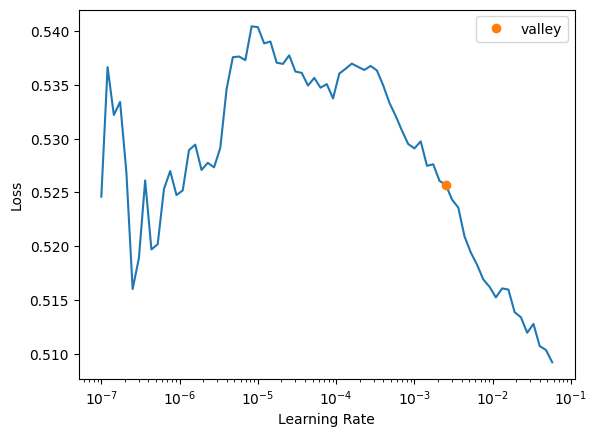

In [10]:
# Learning rate finder
# Pre-trained model typically wants a lower LR than training from scratch
lr_result = learn.lr_find()
LR = lr_result.valley
print(f"Suggested LR: {LR:.2e} — stored in LR variable for training")

In [11]:
# Re-create learner with fresh model + callbacks
model = create_segresnet_with_suprem_weights(PRETRAINED_WEIGHTS, device=DEVICE)
model = model.to(DEVICE)
loss_fn = MaskedCombinedLoss()

comp_metric = CompetitionMetric(
    val_ids, TRAIN_IMG, TRAIN_LBL,
    n_volumes=N_VAL_VOLUMES, threshold=COMP_THRESHOLD,
    patch_size=PATCH_SIZE, stride=96, downsample=METRIC_DOWNSAMPLE,
)

learn = Learner(
    dls,
    model,
    loss_func=loss_fn,
    metrics=[MaskedDiceMetric(), comp_metric],
    splitter=segresnet_splitter,
    cbs=[
        MixedPrecision(),
        SaveModelCallback(monitor="comp_score", comp=np.greater, fname="best_segresnet_v6"),
    ],
    path=CKPT_DIR,
)

# Discriminative LR: encoder=LR/100, decoder=LR/10, head=LR
print(f"Training {EPOCHS} epochs with discriminative LR: slice({LR/100:.2e}, {LR:.2e})")
print(f"  Encoder (SuPreM):  ~{LR/100:.2e}")
print(f"  Decoder:           ~{LR/10:.2e}")
print(f"  Head (random init): {LR:.2e}")
learn.fit_one_cycle(EPOCHS, lr_max=slice(LR/100, LR))

SuPreM weights: loaded 79/83 params, skipped 4 (final conv)
Training 30 epochs with discriminative LR: slice(2.51e-05, 2.51e-03)
  Encoder (SuPreM):  ~2.51e-05
  Decoder:           ~2.51e-04
  Head (random init): 2.51e-03


epoch,train_loss,valid_loss,dice,comp_score,time
0,0.503362,0.507259,0.215254,0.533441,01:30
1,0.473179,0.464498,0.232760,0.537028,01:29
2,0.465052,0.457126,0.242726,0.537119,01:30
3,0.462247,0.442914,0.160982,0.433559,01:29
4,0.458086,0.433663,0.245330,0.513304,01:30
5,0.442222,0.446907,0.210144,0.468310,01:30
6,0.448084,0.441684,0.249771,0.525666,01:30
7,0.450489,0.466262,0.141766,0.422113,01:30
8,0.444881,0.440168,0.222770,0.460708,01:30
9,0.437410,0.454159,0.193595,0.463030,01:31


Better model found at epoch 0 with comp_score value: 0.5334414381126387.
Better model found at epoch 1 with comp_score value: 0.5370284656436726.
Better model found at epoch 2 with comp_score value: 0.5371193827041775.


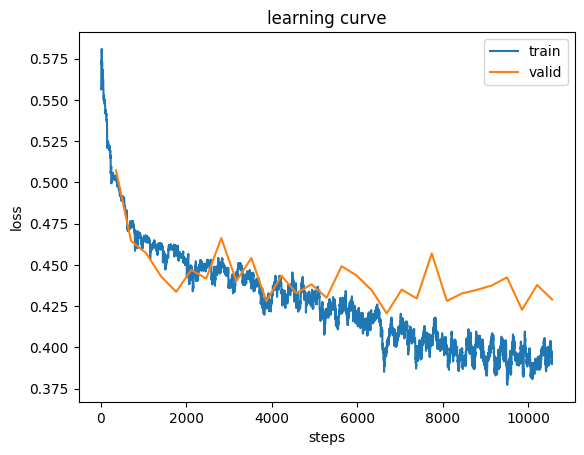

In [12]:
# Plot training curves
learn.recorder.plot_loss()
plt.show()

## 8. Inference & Submission

In [13]:
# Load best model (selected by competition metric, not dice)
learn.load("best_segresnet_v6")
model = learn.model.eval()
print("Best model loaded (selected by comp_score).")

Best model loaded (selected by comp_score).


/home/mongomatt/Projects/vesuvius/vesuvius/lib/python3.12/site-packages/fastai/learner.py:67: UserWarning: Saved file doesn't contain an optimizer state.
  elif with_opt: warn("Saved file doesn't contain an optimizer state.")


In [14]:
# sliding_window_inference() is defined in cell 14 (needed by CompetitionMetric during training)
print("sliding_window_inference already defined above.")

sliding_window_inference already defined above.


### Threshold Tuning on Validation Set

Sweep thresholds 0.3–0.7 on a few validation volumes to find the optimal cutoff.
The default 0.5 may not be best — different loss functions shift the probability distribution.

In [15]:
# Threshold sweep on a subset of validation volumes
# Uses full-volume sliding window inference, so we sample a few to keep it fast

def compute_dice_at_threshold(prob, label_vol, threshold):
    """Compute masked dice for a full volume at a given threshold."""
    mask = (label_vol != 2)
    target = (label_vol == 1)
    pred = (prob > threshold)

    pred_m = pred & mask
    tgt_m = target & mask

    intersection = (pred_m & tgt_m).sum()
    union = pred_m.sum() + tgt_m.sum()
    return (2.0 * intersection + 1.0) / (union + 1.0)


def postprocess(binary_mask, min_component_size=100, closing_radius=2):
    """
    Post-processing to clean up predictions:
    1. Morphological closing — fill small holes in surfaces
    2. Connected component filtering — remove small fragments

    Targets TopoScore (no spurious fragments) and SurfaceDice (smoother surfaces).
    """
    # Morphological closing (fill small gaps/holes)
    struct = np.ones((closing_radius*2+1,)*3, dtype=bool)
    closed = binary_closing(binary_mask, structure=struct)

    # Remove small connected components
    labeled, n_components = scipy_label(closed)
    if n_components > 0:
        component_sizes = np.bincount(labeled.ravel())
        # component_sizes[0] is background, skip it
        small_mask = component_sizes < min_component_size
        small_mask[0] = False  # don't remove background
        closed[small_mask[labeled]] = 0

    return closed.astype(np.uint8)


# Run threshold sweep on a few val volumes
n_sweep = min(10, len(val_ids))  # use up to 10 val volumes
sweep_ids = val_ids[:n_sweep]
thresholds = [0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7]

print(f"Sweeping {len(thresholds)} thresholds on {n_sweep} validation volumes...")
results = {t: [] for t in thresholds}

for i, vid in enumerate(sweep_ids):
    img = tifffile.imread(TRAIN_IMG / f"{vid}.tif")
    lbl = tifffile.imread(TRAIN_LBL / f"{vid}.tif")
    prob = sliding_window_inference(model, img, patch_size=PATCH_SIZE, stride=96, device=DEVICE)

    for t in thresholds:
        # Test with and without post-processing
        dice_raw = compute_dice_at_threshold(prob, lbl, t)
        pred_pp = postprocess((prob > t).astype(np.uint8))
        dice_pp = compute_dice_at_threshold(pred_pp.astype(float), lbl, 0.5)
        results[t].append((dice_raw, dice_pp))

    print(f"  [{i+1}/{n_sweep}] {vid} done")

# Print results
print(f"\n{'Threshold':>10} {'Dice (raw)':>12} {'Dice (PP)':>12}")
print("-" * 36)
best_t, best_dice = 0.5, 0
best_t_pp, best_dice_pp = 0.5, 0
for t in thresholds:
    raw_mean = np.mean([r[0] for r in results[t]])
    pp_mean = np.mean([r[1] for r in results[t]])
    print(f"{t:>10.2f} {raw_mean:>12.4f} {pp_mean:>12.4f}")
    if raw_mean > best_dice:
        best_dice = raw_mean
        best_t = t
    if pp_mean > best_dice_pp:
        best_dice_pp = pp_mean
        best_t_pp = t

print(f"\nBest raw: threshold={best_t}, dice={best_dice:.4f}")
print(f"Best PP:  threshold={best_t_pp}, dice={best_dice_pp:.4f}")
BEST_THRESHOLD = best_t_pp if best_dice_pp > best_dice else best_t
USE_POSTPROCESS = best_dice_pp > best_dice
print(f"\nUsing: threshold={BEST_THRESHOLD}, post-processing={'ON' if USE_POSTPROCESS else 'OFF'}")

Sweeping 9 thresholds on 10 validation volumes...
  [1/10] 26894125 done
  [2/10] 105796630 done
  [3/10] 327851248 done
  [4/10] 418613908 done
  [5/10] 477109023 done
  [6/10] 529850947 done
  [7/10] 568160669 done
  [8/10] 599381487 done
  [9/10] 656697281 done
  [10/10] 730065526 done

 Threshold   Dice (raw)    Dice (PP)
------------------------------------
      0.30       0.2824       0.2810
      0.35       0.2794       0.2835
      0.40       0.2685       0.2768
      0.45       0.2555       0.2662
      0.50       0.2398       0.2519
      0.55       0.2204       0.2334
      0.60       0.1941       0.2076
      0.65       0.1548       0.1673
      0.70       0.0974       0.1051

Best raw: threshold=0.3, dice=0.2824
Best PP:  threshold=0.35, dice=0.2835

Using: threshold=0.35, post-processing=ON


In [16]:
# Run inference on test volumes with optimal threshold + post-processing
test_df = pd.read_csv(ROOT / "test.csv")
submission_dir = ROOT / "submission"
submission_dir.mkdir(exist_ok=True)

for _, row in test_df.iterrows():
    vol_id = row.id
    img_path = TEST_IMG / f"{vol_id}.tif"
    if not img_path.exists():
        print(f"Skipping {vol_id}: file not found")
        continue

    print(f"Predicting {vol_id}...")
    img = tifffile.imread(img_path)

    prob = sliding_window_inference(model, img, patch_size=PATCH_SIZE, stride=96)
    pred = (prob > BEST_THRESHOLD).astype(np.uint8)

    if USE_POSTPROCESS:
        pred = postprocess(pred)

    out_path = submission_dir / f"{vol_id}.tif"
    tifffile.imwrite(out_path, pred)
    fg = pred.sum()
    print(f"  threshold={BEST_THRESHOLD}, PP={'ON' if USE_POSTPROCESS else 'OFF'}")
    print(f"  Saved {out_path} — shape: {pred.shape}, fg: {fg}/{pred.size} ({fg/pred.size*100:.1f}%)")

print("\nInference done.")

Predicting 1407735...
  threshold=0.35, PP=ON
  Saved /home/mongomatt/Projects/vesuvius/submission/1407735.tif — shape: (320, 320, 320), fg: 6817766/32768000 (20.8%)

Inference done.


In [17]:
# Create submission.zip
zip_path = ROOT / "submission.zip"
with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zf:
    for tif in submission_dir.glob("*.tif"):
        zf.write(tif, tif.name)

print(f"Submission zip created: {zip_path}")
print(f"Size: {zip_path.stat().st_size / 1e6:.1f} MB")

Submission zip created: /home/mongomatt/Projects/vesuvius/submission.zip
Size: 1.2 MB


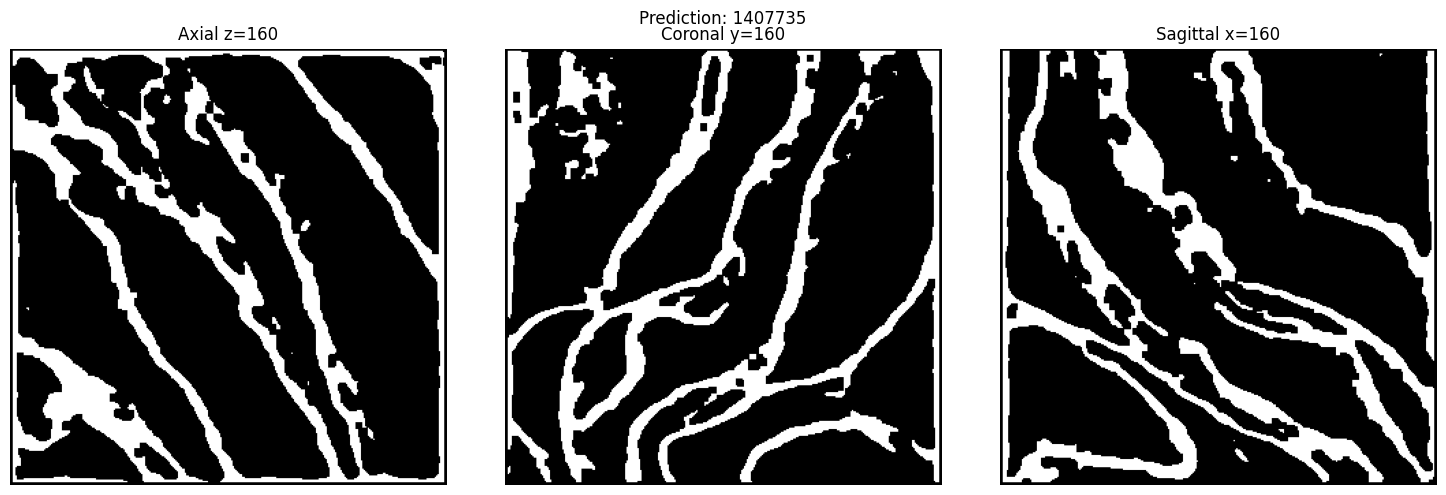

In [18]:
# Visualize a prediction (if test data is available)
if list(submission_dir.glob("*.tif")):
    pred_path = list(submission_dir.glob("*.tif"))[0]
    pred_vol = tifffile.imread(pred_path)
    mid = pred_vol.shape[0] // 2

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(pred_vol[mid], cmap="gray")
    axes[0].set_title(f"Axial z={mid}")
    axes[1].imshow(pred_vol[:, mid], cmap="gray")
    axes[1].set_title(f"Coronal y={mid}")
    axes[2].imshow(pred_vol[:, :, mid], cmap="gray")
    axes[2].set_title(f"Sagittal x={mid}")
    for ax in axes:
        ax.axis("off")
    plt.suptitle(f"Prediction: {pred_path.stem}")
    plt.tight_layout()
    plt.show()